---
This model extends the routing framework by integrating straw logistics. The goal is to minimize the total travel distance for each technician while ensuring the following:

* **Technician starting condition**
  Each technician starts their route at their designated origin node with an initial supply of straws.

* **Route departure from origin**
  Each technician must depart exactly once from their origin node.

* **Flow conservation**
  For each node in the route (excluding the origin), the number of incoming paths must equal the number of outgoing paths.

* **Farmer service enforcement**
  Each farmer must be visited and served exactly once by a technician.

* **No subtours allowed**
  To prevent disconnected loops, the model uses Miller–Tucker–Zemlin (MTZ) constraints to ensure a valid, continuous path for each technician.

  ---

  This sample assignment is derived from the results of the previous resource allocation model. In this case, Technician 4 is assigned to farmers 0, 2, 6, and 7, while Technician 8 is assigned to farmers 3, 5, 9, 10, and 11. The technicians begin with 2 and 1 straws, respectively. They may replenish straws by visiting the office located at node 1, where Technician 4 can refill 2 straws per visit and Technician 8 can refill 4.

  ---

In [ ]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 50.0 MB/s eta 0:00:00


---
To demonstrate the solution of the bi-objective optimization problem, we use a sample network consisting of 12 nodes (representing the office, technicians, and farmers) interconnected by 20 edges. This model demonstrates technician route planning using Gurobi.

---


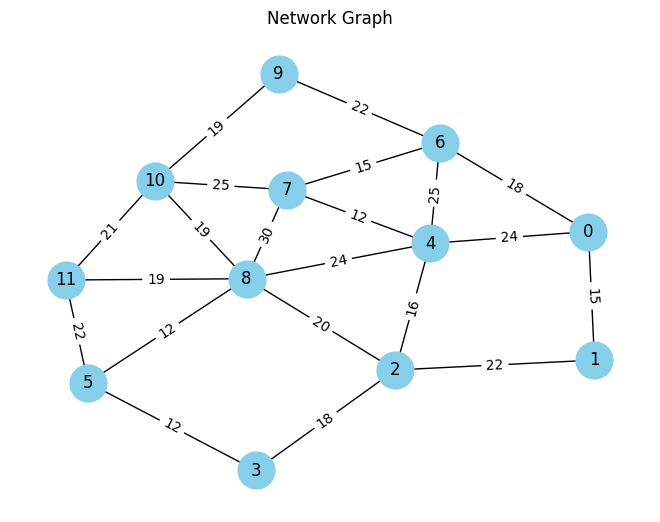

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Edge-based node-to-node distance matrix
distance= np.array([
    [0, 15, 0, 0, 24, 0, 18, 0, 0, 0, 0, 0],
    [15, 0, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 22, 0, 18, 16, 0, 0, 0, 20, 0, 0, 0],
    [0, 0, 18, 0, 0, 12, 0, 0, 0, 0, 0, 0],
    [24, 0, 16, 0, 0, 0, 25, 12, 24, 0, 0, 0],
    [0, 0, 0, 12, 0, 0, 0, 0, 12, 0, 0, 22],
    [18, 0, 0, 0, 25, 0, 0, 15, 0, 22, 0, 0],
    [0, 0, 0, 0, 12, 0, 15, 0, 30, 0, 25, 0],
    [0, 0, 20, 0, 24, 12, 0, 30, 0, 0, 19, 19],
    [0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 19, 0],
    [0, 0, 0, 0, 0, 0, 0, 25, 19, 19, 0, 21],
    [0, 0, 0, 0, 0, 22, 0, 0, 19, 0, 21, 0]
])

def plot_graph(distance_matrix):
    G = nx.Graph()

    # Add nodes to the graph
    n = len(distance_matrix)
    G.add_nodes_from(range(n))

    # Add edges to the graph with weights from the distance matrix
    for i in range(n):
        for j in range(n):
            if distance_matrix[i][j] != 0:
                G.add_edge(i, j, weight=distance_matrix[i][j])

    # Draw the graph
    pos = nx.spring_layout(G)
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
    plt.title("Network Graph")
    plt.show()

plot_graph(distance)

---
Since the input is provided as an edge-based node-to-node distance  matrix, we compute the farmer-to-technician shortest distance matrix using Dijkstra’s algorithm.

---

In [ ]:
import numpy as np
import networkx as nx

def djikstra(distance_matrix):

    num_nodes = distance_matrix.shape[0]

    # Build the graph
    G = nx.Graph()
    for i in range(num_nodes):
        for j in range(num_nodes):
            if distance_matrix[i, j] > 0 and i != j:
                G.add_edge(i, j, weight=distance_matrix[i, j])

    # Compute all-pairs shortest paths in one efficient call
    all_pairs_dist = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))

    # Initialize and populate the final matrix
    full_distance = np.full((num_nodes, num_nodes), 9999.0)
    for start_node, distances in all_pairs_dist.items():
        for end_node, dist in distances.items():
            full_distance[start_node, end_node] = dist

    # Set self-loops to 0
    np.fill_diagonal(full_distance, 0.0)

    return full_distance

num_nodes = distance.shape[0]
full_distance = np.zeros((num_nodes, num_nodes))
full_distance =  djikstra(distance)

print("Node-to-Node Shortest Distance Matrix:")
print(full_distance)

Node-to-Node Shortest Distance Matrix:
[[ 0. 15. 37. 55. 24. 60. 18. 33. 48. 40. 58. 67.]
 [15.  0. 22. 40. 38. 52. 33. 48. 42. 55. 61. 61.]
 [37. 22.  0. 18. 16. 30. 41. 28. 20. 58. 39. 39.]
 [55. 40. 18.  0. 34. 12. 59. 46. 24. 62. 43. 34.]
 [24. 38. 16. 34.  0. 36. 25. 12. 24. 47. 37. 43.]
 [60. 52. 30. 12. 36.  0. 57. 42. 12. 50. 31. 22.]
 [18. 33. 41. 59. 25. 57.  0. 15. 45. 22. 40. 61.]
 [33. 48. 28. 46. 12. 42. 15.  0. 30. 37. 25. 46.]
 [48. 42. 20. 24. 24. 12. 45. 30.  0. 38. 19. 19.]
 [40. 55. 58. 62. 47. 50. 22. 37. 38.  0. 19. 40.]
 [58. 61. 39. 43. 37. 31. 40. 25. 19. 19.  0. 21.]
 [67. 61. 39. 34. 43. 22. 61. 46. 19. 40. 21.  0.]]


In [ ]:
import gurobipy as gp

def technician_routing_withoutstraws(all_nodes, farmers, technicians, offices, full_distance):

    # Gurobi Model Creation
    m = gp.Model("TechnicianRoutingwithoutStraws")

    # Decision Variables
    x = m.addVars(all_nodes, all_nodes, technicians, vtype=gp.GRB.BINARY, name="x")
    r = m.addVars(all_nodes, technicians, lb=0, vtype=gp.GRB.INTEGER, name="r")

    # Objective Function
    m.setObjective(gp.quicksum(full_distance[i][j] * x[i, j, t]
                               for i in all_nodes
                               for j in all_nodes
                               for t in technicians), gp.GRB.MINIMIZE)

    # Constraints

    # 1. Start at Origin
    for t in technicians:
        m.addConstr(gp.quicksum(x[t, j, t] for j in all_nodes if j != t) == 1,
                    name=f"Start_at_Origin_{t}")

    # 2. Flow Conservation
    for t in technicians:
        for j in all_nodes:
            if j != t:
                m.addConstr(gp.quicksum(x[i, j, t] for i in all_nodes if i != j) -
                            gp.quicksum(x[j, k, t] for k in all_nodes if k != j) == 0,
                            name=f"Flow_Conservation_{j}_{t}")

    # 3. Farmers Must Be Visited (Exactly once)
    for f in farmers:
        m.addConstr(gp.quicksum(gp.quicksum(x[i, f, t] for i in all_nodes if i != f)
                                for t in technicians) == 1,
                    name=f"Farmer_Visited_{f}")

    # 4. Subtour Elimination (MTZ formulation)
    u = m.addVars(all_nodes, technicians, vtype=gp.GRB.INTEGER, name="u")
    N = len(all_nodes)
    for t in technicians:
        for i in all_nodes:
            for j in all_nodes:
                if i != j and i != t and j != t:
                    m.addConstr(u[i, t] - u[j, t] + N * x[i, j, t] <= N - 1,
                                name=f"Subtour_Elimination_{i}_{j}_{t}")

    # Solve and Display
    m.optimize()

    status_dict = {
        gp.GRB.OPTIMAL: "OPTIMAL",
        gp.GRB.INFEASIBLE: "INFEASIBLE",
        gp.GRB.UNBOUNDED: "UNBOUNDED",
        gp.GRB.INF_OR_UNBD: "INFEASIBLE OR UNBOUNDED",
        gp.GRB.TIME_LIMIT: "TIME LIMIT REACHED",
        gp.GRB.INTERRUPTED: "INTERRUPTED",
        gp.GRB.SUBOPTIMAL: "SUBOPTIMAL"
    }

    print(f"Optimization Status: {status_dict.get(m.Status, 'UNKNOWN')} ({m.Status})")

    if m.Status == gp.GRB.INFEASIBLE:
        print("\nModel is INFEASIBLE. Computing IIS...")
        m.computeIIS()
        m.write("model.ilp")
        print("IIS written to model.ilp")
        return None

    elif m.Status == gp.GRB.OPTIMAL:
        routes = {}
        for t in technicians:
            print("\n" + "=" * 80)
            print(f"Technician {t} Route:")
            print("-" * 80)
            print(f"{'Step':<5} {'Node':<6} {'Type':<30} {'Step Dist':<10} {'Cumulative Dist'}")
            print("-" * 80)

            route_map = {}
            for i in all_nodes:
                for j in all_nodes:
                    if i != j and x[i, j, t].X > 0.5:
                        route_map[i] = j

            current = t
            cumulative_dist = 0
            step = 0
            tech_route = []

            while current in route_map:
                next_node = route_map[current]
                dist = full_distance[current][next_node]
                cumulative_dist += dist

                # Determine node type for printing
                if next_node in offices:
                    node_type = f"🏢 Office"
                elif next_node in farmers:
                    node_type = "🐃 Farmer ✅ Served"
                elif next_node == t:
                    node_type = "🏠 Technician Origin (End)"
                else:
                    node_type = "➡️ Passed Through"

                print(f"{step:<5} {next_node:<6} {node_type:<30} {dist:<10.2f} {cumulative_dist:.2f}")
                tech_route.append((next_node, node_type, dist, cumulative_dist))

                current = next_node
                step += 1
                if current == t: # Break the loop when the route returns to the origin
                    break

            routes[t] = tech_route

        print("\n" + "=" * 80)
        print("Total Objective Value (Total Distance): ", m.ObjVal)
        print("=" * 80)
        return routes, m.ObjVal

---
This is the first sample problem (without farmer preference) used to demonstrate the model. The key elements are as follows:

* **Technicians:** Nodes 4 and 8 are designated as AI technicians.
* **Farmers:** Nodes 0, 2, 3, 5, 6, 7, 9, 10, and 11 represent farmers that need to be assigned to a technician.
* **Office:** Node 1 serves as the central office or semen bank, where technicians can refill their straws.
---

In [ ]:
farmers = [0, 2, 3, 5, 6, 7, 9, 10, 11]
technicians = [4, 8]
offices = [1]
all_nodes = list(range(distance.shape[0]))

In [ ]:
routes, total_distance = technician_routing_withoutstraws(all_nodes, farmers, technicians, offices, full_distance)

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 253 rows, 336 columns and 1364 nonzeros
Model fingerprint: 0x8c4b0060
Variable types: 0 continuous, 336 integer (288 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+01, 7e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]
Presolve removed 0 rows and 50 columns
Presolve time: 0.01s
Presolved: 253 rows, 286 columns, 1364 nonzeros
Variable types: 0 continuous, 286 integer (264 binary)

Root relaxation: objective 1.870000e+02, 59 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  187.00000    0   18          -  187.00000

In [ ]:
print(routes)

{4: [(7, '🐃 Farmer ✅ Served', np.float64(12.0), np.float64(12.0)), (4, '🏠 Technician Origin (End)', np.float64(12.0), np.float64(24.0))], 8: [(5, '🐃 Farmer ✅ Served', np.float64(12.0), np.float64(12.0)), (3, '🐃 Farmer ✅ Served', np.float64(12.0), np.float64(24.0)), (2, '🐃 Farmer ✅ Served', np.float64(18.0), np.float64(42.0)), (1, '🏢 Office', np.float64(22.0), np.float64(64.0)), (0, '🐃 Farmer ✅ Served', np.float64(15.0), np.float64(79.0)), (6, '🐃 Farmer ✅ Served', np.float64(18.0), np.float64(97.0)), (9, '🐃 Farmer ✅ Served', np.float64(22.0), np.float64(119.0)), (10, '🐃 Farmer ✅ Served', np.float64(19.0), np.float64(138.0)), (11, '🐃 Farmer ✅ Served', np.float64(21.0), np.float64(159.0)), (8, '🏠 Technician Origin (End)', np.float64(19.0), np.float64(178.0))]}


---
This visualization illustrates the network of farmers, technicians, and the office using NetworkX and Matplotlib. Connections between nodes are determined by the non-zero entries in the distance matrix, with edge labels indicating the corresponding distances.

* Farmers assigned to the same technician are represented by nodes of the same color.
* Technician nodes share the same color as their assigned farmers for clear grouping.
* Directed arrows indicate the technician’s route, with arrow colors matching both the technician and their assigned farmers.
* The office node is highlighted in yellow to distinguish it from technician-farmer groups.
* A legend identifies each technician’s assigned color, while a spring layout provides improved spacing and readability.

---

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_routes(all_nodes, full_distance, routes, technicians, offices, farmers):

    G = nx.DiGraph()
    G.add_nodes_from(all_nodes)

    for i in all_nodes:
        for j in all_nodes:
            if i != j and full_distance[i][j] != 0:
                G.add_edge(i, j, weight=full_distance[i][j])

    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(14, 10))

    # Base Graph (Grey)
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightgray')
    nx.draw_networkx_labels(G, pos, labels={i: str(i) for i in all_nodes}, font_size=9)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1.5, arrows=False, alpha=0.5)

    # Edge Distance Labels
    edge_labels = {(i, j): f"d={G[i][j]['weight']}" for i, j in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray', font_size=8, rotate=False)

    # Colors and Arcs
    colors = ['red', 'teal', 'orange', 'green', 'purple', 'brown', 'cyan', 'magenta', 'lime', 'navy']
    base_offsets = [0.12, -0.12, 0.2, -0.2, 0.3, -0.3]
    offset_map = {idx: base_offsets[idx % len(base_offsets)] for idx in range(len(technicians))}

    for idx, t in enumerate(technicians):
        tech_route = [t] + [step[0] for step in routes.get(t, [])]  # ordered nodes
        tech_edges = [(tech_route[i], tech_route[i+1]) for i in range(len(tech_route)-1)]
        color = colors[idx % len(colors)]
        offset = offset_map.get(idx, 0.1 * (-1)**idx)

        # Draw edges for technician
        nx.draw_networkx_edges(
            G, pos,
            edgelist=tech_edges,
            edge_color=color,
            width=3,
            arrows=True,
            arrowsize=20,
            connectionstyle=f"arc3,rad={offset}"
        )

        # Technician origin node
        nx.draw_networkx_nodes(G, pos, nodelist=[t], node_color=color, node_size=800, node_shape='*', label=f'Tech {t}')

        # Farmer nodes served
        served_farmers = [node for node, _, _, _ in routes.get(t, []) if node in farmers]
        nx.draw_networkx_nodes(G, pos, nodelist=served_farmers, node_color=color, node_size=500, node_shape='s')

    # Office nodes
    nx.draw_networkx_nodes(G, pos, nodelist=offices, node_color='gold', node_shape='^', node_size=700, label='Office')

    plt.title("Technician Routes")
    plt.legend()
    plt.axis("off")
    plt.tight_layout()
    plt.show()


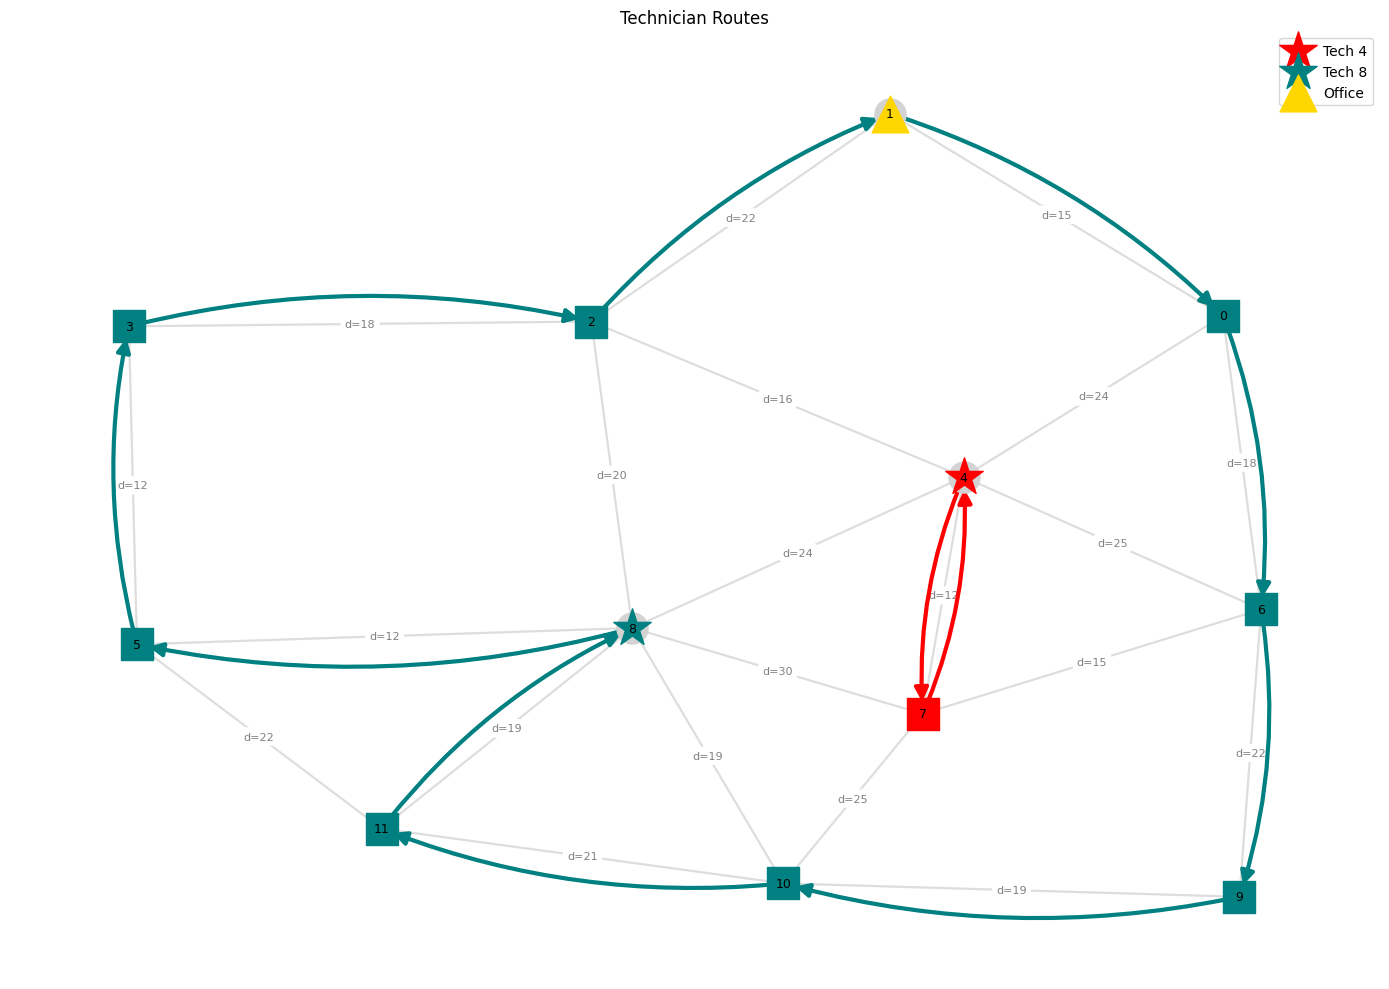

In [ ]:
plot_routes(all_nodes, distance, routes, technicians, offices, farmers)


This is the second sample problem (with farmer preference) used to test the model. The key elements are:

* **Technicians:** Nodes 0, 4, and 5 are designated as AI technicians.
* **Farmers:** Nodes 1, 2, 3, 6, 7, 9, 10, and 11 require insemination services.
* **Office:** Node 8 serves as the central office or semen bank where technicians can refill their straws.



In [ ]:
technicians = [0, 4, 5]
farmers = [1, 2, 3, 6, 7, 9, 10, 11]
offices = [8]

In [ ]:
routes, total_distance = technician_routing_withoutstraws(all_nodes, farmers, technicians, offices, full_distance)

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 374 rows, 504 columns and 2013 nonzeros
Model fingerprint: 0xd7607195
Variable types: 0 continuous, 504 integer (432 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+01, 7e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]
Presolve removed 0 rows and 75 columns
Presolve time: 0.01s
Presolved: 374 rows, 429 columns, 2013 nonzeros
Variable types: 0 continuous, 429 integer (396 binary)

Root relaxation: objective 1.870000e+02, 74 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0  187.00000    0   18          -  187.00000

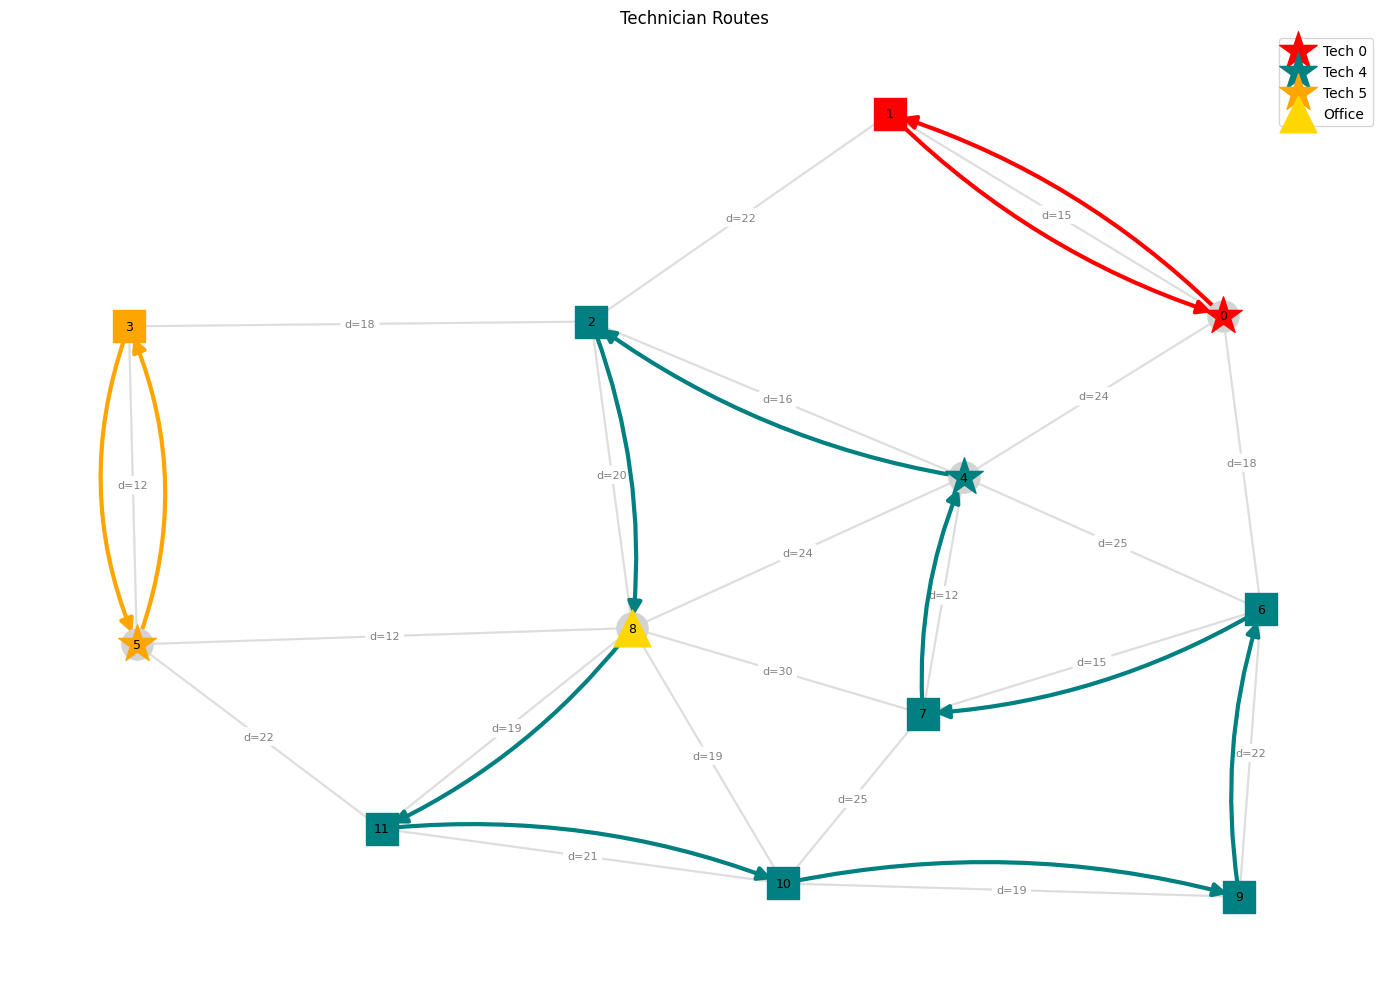

In [ ]:
plot_routes(all_nodes, distance, routes, technicians, offices, farmers)